# Specifying the trend with `terms`

Every MOOGP model has a deterministic **trend** $g(x)$ — a small set of basis
functions whose coefficients are fit by generalized least squares, separately
from the latent GPs. `terms` lists the columns of $g(x)$. Each entry is:

  * `None` — an intercept (a column of ones),
  * an int `j` — the main effect of input `j` (1-based by default),
  * a tuple — an interaction, e.g. `(1, 2)` for $x_1 x_2$.

```python
terms = [None, 1, 2, 3]        # g(x) = [1, x1, x2, x3]
terms = [None, 1, 2, (1, 2)]   # g(x) = [1, x1, x2, x1*x2]
```

Because the latent kernels are *orthogonalized* against $g(x)$ (when
`orthogonal=True`), the trend captures the part of the response it can explain
and its coefficients stay interpretable. This notebook shows how `terms` maps to
columns of $g(x)$ and how the choice shapes the fitted trend.

In [1]:
# !pip install moogp
# !pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

from moogp.model import MOOGP
from moogp.design import make_G
from moogp.datasets import generate_forrester_data

## 1. How `terms` maps to columns of $g(x)$

`make_G` builds the trend design matrix. Passing `return_names=True` shows
exactly which column each entry of `terms` produces.

In [2]:
X_demo = np.random.default_rng(0).standard_normal((4, 3))  # 4 points, 3 inputs

for terms in ([None], [None, 1], [None, 1, 2, 3], [None, 1, 2, (1, 2)]):
    _, names = make_G({"X_scaled": X_demo}, terms, one_based=True, return_names=True)
    print(f"terms={str(terms):24s} ->  g(x) = [{', '.join(names)}]")

terms=[None]                   ->  g(x) = [1]
terms=[None, 1]                ->  g(x) = [1, x1]
terms=[None, 1, 2, 3]          ->  g(x) = [1, x1, x2, x3]
terms=[None, 1, 2, (1, 2)]     ->  g(x) = [1, x1, x2, x1*x2]


## 2. The trend inside a fit: intercept-only vs linear

We fit the 1-D Forrester data with two trend specifications and isolate the
fitted trend $g(x)^\top \hat\beta$. The helper below evaluates that trend on
the original output scale (undoing the model's internal standardization).

In [3]:
def trend_on_raw_scale(model, Xstar):
    """Evaluate the fitted trend g(x)^T bhat on the original output scale."""
    Xw = model._to_working_x(np.asarray(Xstar))
    Gs = make_G({"X_scaled": Xw}, model.terms,
                one_based=model.one_based, return_names=False)
    return model._from_working_mean(Gs @ model.cache["bhat"])


data = generate_forrester_data(n=40, seed=3, with_error=True,
                               error_per_output=[10.0, 1.0, 0.05])
X, Y, F = data["X"], data["y"], data["f"]

models = {}
for label, terms in [("intercept only  [None]", [None]),
                     ("linear  [None, 1]", [None, 1])]:
    m = MOOGP(terms=terms, q=3, orthogonal=True, learn_sigma_eps=True)
    m.fit(data)
    models[label] = m

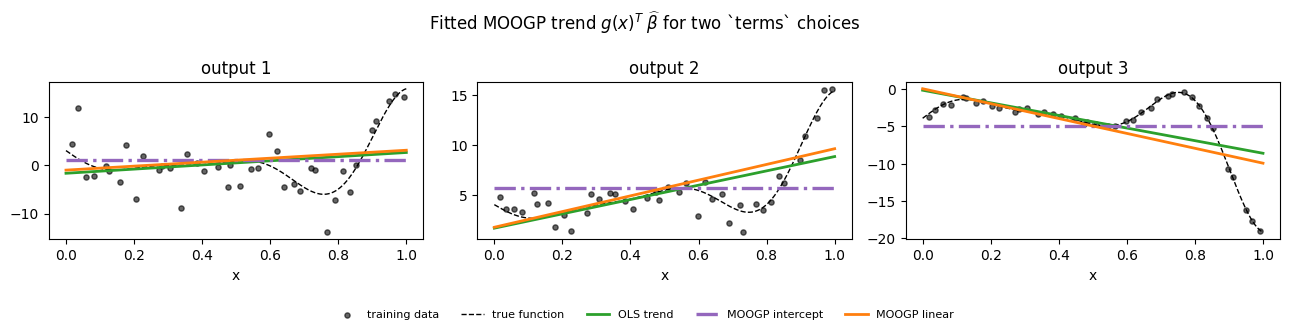

In [22]:
xg = np.linspace(0, 1, 300).reshape(-1, 1)
Fg = generate_forrester_data(n=300, seed=3, X_override=xg)["f"]
# A reference "true" linear trend: ordinary least squares on the dense truth.
G_ols = np.column_stack([np.ones(300), xg[:, 0]])
beta_ols, *_ = np.linalg.lstsq(G_ols, Fg, rcond=None)
trend_ols = G_ols @ beta_ols

legend_labels = {"intercept only  [None]": "MOOGP intercept", "linear  [None, 1]": "MOOGP linear"}
model_styles = {
    "intercept only  [None]": dict(color="tab:purple", linestyle="-.", lw=2.4),
    "linear  [None, 1]": dict(color="tab:orange", linestyle="-", lw=2),
}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharex=True)
for j, ax in enumerate(axes):
    add_labels = (j == 0)
    ax.scatter(X[:, 0], Y[:, j], s=14, c="k", alpha=0.6, label="training data" if add_labels else None)
    ax.plot(xg[:, 0], Fg[:, j], "k--", lw=1, label="true function" if add_labels else None)
    ax.plot(xg[:, 0], trend_ols[:, j], color="tab:green", lw=2, label="OLS trend" if add_labels else None)
    for label, m in models.items():
        ax.plot(xg[:, 0], trend_on_raw_scale(m, xg)[:, j],
                label=legend_labels[label] if add_labels else None,
                **model_styles[label])
    ax.set_title(f"output {j + 1}")
    ax.set_xlabel("x")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels),
           frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(r"Fitted MOOGP trend $g(x)^T \; \widehat\beta$ for two `terms` choices")
fig.tight_layout(rect=(0, 0.08, 1, 1))

The intercept-only trend is flat (a per-output constant), so all of the
structure is left to the latent GPs. The linear trend `[None, 1]` captures the
global slope; with `orthogonal=True` its slope/intercept closely track the
least-squares line. Because the trend is fit by GLS rather than after the fact,
the coefficients are directly interpretable:

In [23]:
m_lin = models["linear  [None, 1]"]
# bhat is on the working scale; map back to raw-x, raw-y for interpretation.
b_raw = trend_on_raw_scale  # reuse helper at two points to recover intercept/slope
g0 = b_raw(m_lin, np.zeros((1, 1)))[0]   # trend at x = 0  -> intercept
g1 = b_raw(m_lin, np.ones((1, 1)))[0]    # trend at x = 1
slope = g1 - g0
print("MOOGP linear trend  intercept:", np.round(g0, 3), " slope:", np.round(slope, 3))
print("OLS linear trend    intercept:", np.round(beta_ols[0], 3),
      " slope:", np.round(beta_ols[1], 3))

MOOGP linear trend  intercept: [-1.016  1.754  0.032]  slope: [ 4.115  7.846 -9.967]
OLS linear trend    intercept: [-1.668  1.666 -0.166]  slope: [ 4.302  7.151 -8.441]


## 3. Interactions for multi-dimensional inputs

For higher-dimensional inputs, `terms` extends naturally — and the fitted trend
coefficients remain interpretable. We build a 2-D problem whose trend
contains an interaction,
$g(x) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_{12}\, x_1 x_2$, plus a
small GP wiggle. Including `(1, 2)` in `terms` lets MOOGP recover that
interaction coefficient by generalized least squares.

In [6]:
rng = np.random.default_rng(1)

def se2(X, ell=0.6):
    d2 = ((X[:, None, :] - X[None, :, :]) ** 2).sum(-1)
    return np.exp(-0.5 * d2 / ell ** 2)

n = 150
X2 = rng.uniform(-1, 1, size=(n, 2))
x1, x2 = X2[:, 0], X2[:, 1]
L = np.linalg.cholesky(se2(X2) + 1e-8 * np.eye(n))
gp_wiggle = 0.25 * (L @ rng.standard_normal((n, 2)))   # small GP component, 2 outputs

B_true = np.array([[ 2.0, -1.0],    # intercept
                   [ 1.5,  0.5],    # x1
                   [-2.0,  1.0],    # x2
                   [ 3.0, -2.5]])   # x1 * x2  (the interaction)
G_true = np.column_stack([np.ones(n), x1, x2, x1 * x2])
Y2 = G_true @ B_true + gp_wiggle + rng.normal(0, 0.05, size=(n, 2))

# Pass inputs already on [-1, 1] and skip standardization so that bhat is
# directly in the raw [1, x1, x2, x1*x2] basis and can be read off.
m_int = MOOGP(terms=[None, 1, 2, (1, 2)], q=2, orthogonal=True,
              learn_sigma_eps=True, standardize_x=False, standardize_y=False)
m_int.fit({"X": X2, "Y": Y2}, optimizer_opts={"maxiter": 400})

_, names = make_G({"X_scaled": X2[:1]}, m_int.terms, one_based=True, return_names=True)
print("trend columns:", names)
print()
print("recovered bhat:")
print(np.round(m_int.cache["bhat"], 2))
print("\ntrue coefficients:")
print(B_true)

trend columns: ['1', 'x1', 'x2', 'x1*x2']

recovered bhat:
[[ 2.01 -1.07]
 [ 1.44  0.49]
 [-1.84  1.13]
 [ 2.96 -2.65]]

true coefficients:
[[ 2.  -1. ]
 [ 1.5  0.5]
 [-2.   1. ]
 [ 3.  -2.5]]


The recovered coefficients track the true ones row by row — including the
`x1*x2` interaction. Because the latent kernels are orthogonalized against
$g(x)$, the GP component does not steal signal that the trend explains, so these
coefficients are more meaningful.

### Takeaways

  * `terms` is the trend basis: `None` (intercept), int (main effect), tuple
    (interaction).
  * A richer trend explains more structure deterministically and leaves less for
    the latent GPs; an intercept-only trend pushes everything into the GPs.
  * With `orthogonal=True` the trend coefficients stay interpretable — see
    [`06_kernel_and_mixing_matrix.ipynb`](06_kernel_and_mixing_matrix.ipynb) for
    why orthogonalization matters.